
# Workshop: Modeling the Effect of Lifestyle Factors on Academic Performance

Can we explain student academic performance using lifestyle variables such as study time, sleep, and social habits?

In this workshop, we will:
*   Explore a real-world student lifestyle dataset
*   Specify a statistical model
*   Fit a linear regression model
*   Interpret results
*   Check key model assumptions

## 1.Setup

### Note on data loading
- If working **locally**: make sure the CSV file is in the same folder as this notebook.
- If working in **Google Colab**: upload the CSV file when prompted.

In [ ]:
import pandas as pd

df = pd.read_csv("student_lifestyle_dataset.csv")
df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


## 2.Exploratory Data Analysis

We start by exploring the dataset:
- What variables are available?
- Are there missing values?
- Is GPA a continuous variable?


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


The dataset contains 2000 observations and 8 variables, with no missing values.
All lifestyle variables and GPA are continuous numeric variables, making them suitable for linear regression.
Student_ID is an identifier and is not used in modeling, while Stress_Level is categorical and excluded to keep the model simple and interpretable.

Now we think about:


*   What is the dependent variable?
*   Which variables could influence it?

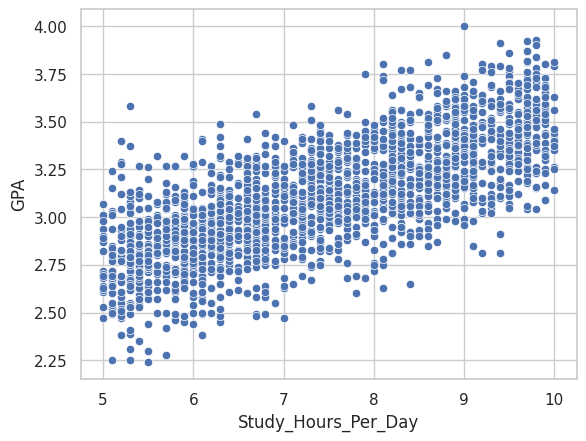

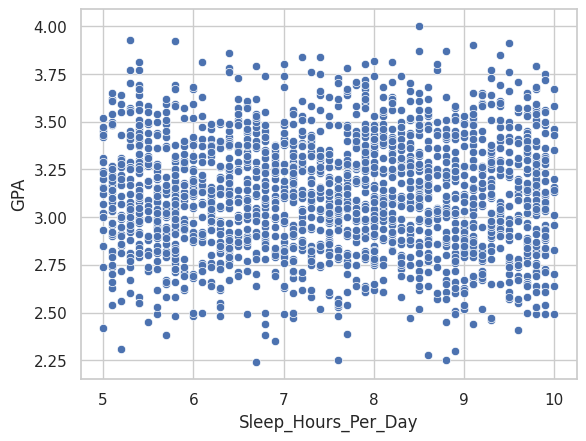

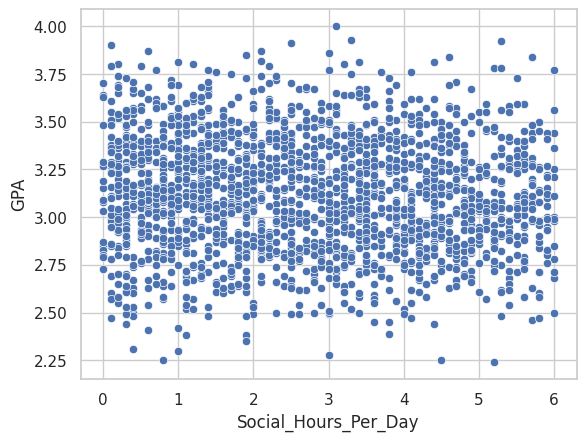

In [ ]:
# TODO: Create scatterplots to explore relationship between variables
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

sns.scatterplot(x="Study_Hours_Per_Day", y="GPA", data=df)
plt.show()

sns.scatterplot(x="Sleep_Hours_Per_Day", y="GPA", data=df)
plt.show()

sns.scatterplot(x="Social_Hours_Per_Day", y="GPA", data=df)
plt.show()


*   **Study Hours per Day vs GPA** The scatterplot shows a clear and strong positive relationship between study hours per day and GPA.
As study time increases, GPA tends to increase steadily.
Although there is some variability, the overall pattern is approximately linear, which supports the use of a linear regression model.
*   **Sleep Hours per Day vs GPA** The relationship between sleep hours and GPA appears weak and diffuse.
There is no strong visible linear trend, suggesting that sleep hours alone do not strongly explain differences in GPA in this dataset.
*   **Social Hours per Day vs GPA** The scatterplot indicates no clear relationship between social hours per day and GPA.
GPA values appear broadly spread across all levels of social activity, suggesting a very weak or negligible linear association.

## 3.Model specification

We define:
- **Dependent variable (Y):** GPA
- **Independent variables (X):**
  - Study_Hours_Per_Day
  - Sleep_Hours_Per_Day
  - Social_Hours_Per_Day

We will use a **multiple linear regression model**.

In [ ]:
# TODO: Specify X and y
import statsmodels.api as sm

X = df[
    [
        "Study_Hours_Per_Day",
        "Sleep_Hours_Per_Day",
        "Social_Hours_Per_Day"
    ]
]
X = sm.add_constant(X)
y = df["GPA"]

## 4. Fitting the model

Fit the linear regression model using Ordinary Least Squares (OLS)


In [ ]:
# TODO: Fit the model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    GPA   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     781.5
Date:                Sun, 14 Dec 2025   Prob (F-statistic):               0.00
Time:                        12:53:54   Log-Likelihood:                 356.27
No. Observations:                2000   AIC:                            -704.5
Df Residuals:                    1996   BIC:                            -682.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.9885 


Answer the following questions:
- Which variable has the strongest effect on GPA?
- Which effects are weak?
- What does the R² value tell us in this context?

*-> The model explains approximately 54% of the variance in GPA (R² = 0.540), which is considered a reasonably strong fit for behavioral and educational data.
The F-statistic is highly significant (p < 0.001), indicating that the model as a whole provides a better fit than a model with no predictors.*

Coefficient interpretation:

*   **Study hours per day** have a strong, positive, and statistically significanteffect on GPA (β ≈ 0.155, p < 0.001).
This means that, on average, an additional hour of study per day is associated with an increase of about 0.15 GPA points, holding other variables constant.
*   **Sleep hours per day** show a small and statistically non-significant effect on GPA (p ≈ 0.16).
This suggests that, once study time and social hours are accounted for, sleep hours do not meaningfully explain additional variation in GPA in this dataset.
*   **Social hours per day** have a very weak and non-significant association with GPA (p ≈ 0.46).
This aligns with the scatterplot, which showed no clear linear relationship.



## 5.Diagnostics & assumptions

We visually check:
- Linearity
- Homoscedasticity
- Normality of residuals

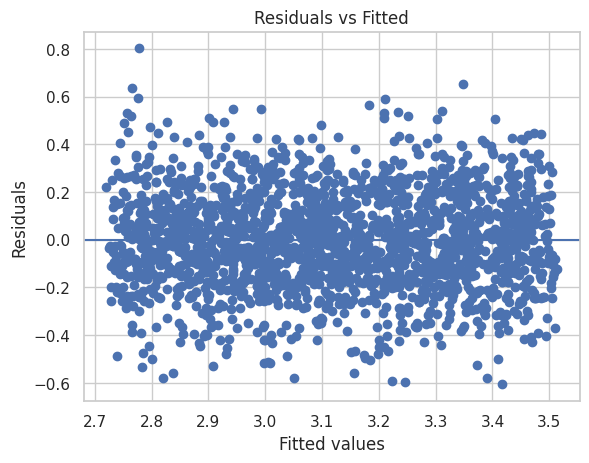

In [ ]:
# TODO: Residuals vs Fitted Values plot

plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

The residuals are randomly scattered around zero with no clear pattern or funnel shape.
This suggests that the assumptions of linearity and homoscedasticity are reasonably satisfied.


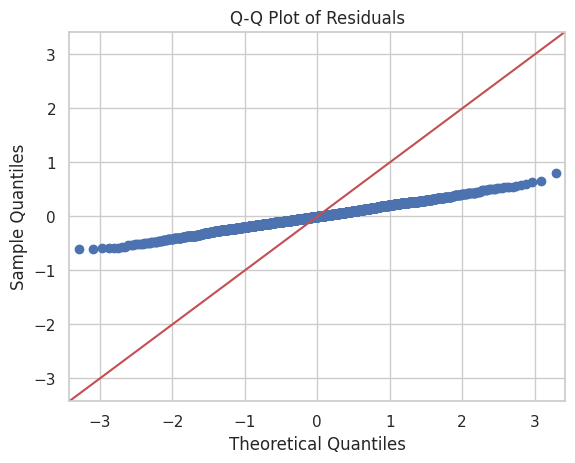

In [ ]:
# TODO: Q-Q plot of residuals
sm.qqplot(model.resid, line="45")
plt.title("Q-Q Plot of Residuals")
plt.show()

The Q–Q plot shows clear deviations from the diagonal line, particularly at the tails, indicating that the residuals are not normally distributed.

This is not unexpected in this context: GPA is a bounded outcome variable, which naturally limits the range and shape of residuals. As a result, the residual distribution appears compressed relative to a standard normal distribution.

While the normality assumption is violated, this is unlikely to substantially affect coefficient estimates in a large sample. However, it may impact inference at the tails, and results should be interpreted with appropriate caution.

## 6.Wrap-up & reflection

### Why use a statistical model instead of simple descriptions?

Descriptive statistics and scatterplots help us understand patterns in the data, but they do not provide a structured way to quantify relationships or uncertainty.

A statistical model formalizes assumptions about how the outcome variable is generated and allows us to model the *expected value* of GPA, E[Y], as a function of several predictors. This makes it possible to:
- Compare the relative importance of variables
- Quantify uncertainty using confidence intervals
- Evaluate model assumptions and limitations

### What does the model actually predict?

The linear regression model does not predict exact GPA values for individual students.
Instead, it models the expected GPA, E[Y], given certain lifestyle characteristics.

Individual outcomes may vary substantially around this expectation due to unobserved factors such as motivation, prior knowledge, stress, or exam difficulty.


### Can we interpret the relationship between study hours and GPA as causal? Why or why not?

This analysis is based on observational data.
Although study hours show a strong association with GPA, this does not imply a causal effect.

Students who study more may differ systematically in other unobserved ways (e.g., motivation or academic ability). Establishing causality would require a controlled experiment or stronger causal assumptions.


### What does it mean that the model explains about 54% of the variance in GPA, and what does the remaining unexplained variance represent?

The model explains about 54% of the variance in GPA, which is substantial for behavioral data but also highlights that a large portion of variability remains unexplained.

Although GPA is technically bounded and discrete at a fine scale, it behaves approximately like a continuous variable in practice, which justifies the use of linear regression.


### Which assumptions of linear regression apply to the error term, and how do these differ from assumptions about the predictors themselves?

Most linear regression assumptions concern the error term ε rather than the predictors themselves.
Linearity refers to the relationship between predictors and the expected outcome, not to the raw data points forming a perfect line.

Minor deviations from assumptions are expected in real-world data, and models remain useful as long as they capture the main structure.


### In what sense is this model “wrong”, and in what sense is it still useful?

All statistical models are simplifications of reality.
While this model does not fully describe academic performance, it provides a useful framework for understanding key relationships, quantifying uncertainty, and making transparent assumptions.

In this sense, the model is not “true” but it is useful.
